## Tema 8.2 — Presentación visual efectiva para tomadores de decisiones

### Visualización “incorrecta” para tomadores de decisiones

Registros: 15000
Columnas: ['ID_Cliente', 'Sector_Negocio', 'Tiempo_en_Servicio_Meses', 'Transacciones_Ult_Mes', 'Tasa_Uso_Caracteristica_X', 'Ingresos_Previstos_USD', 'Costo_Retencion_USD', 'Etiqueta_Real', 'Probabilidad_Modelo', 'Prediccion_Modelo']


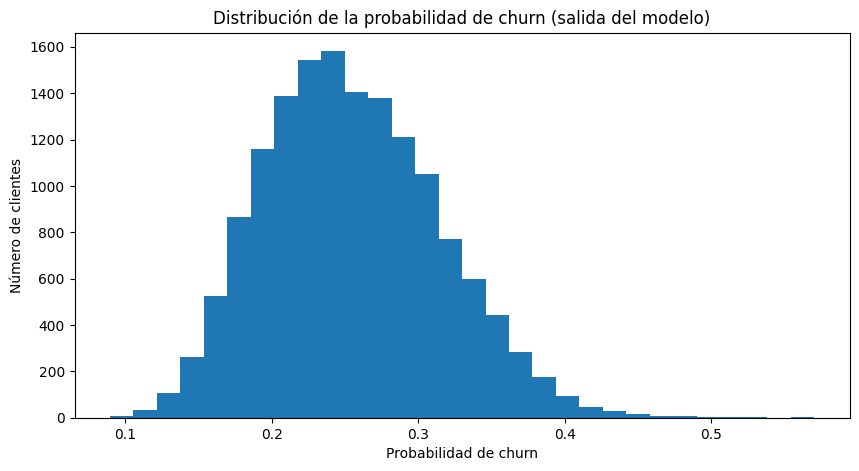

In [3]:

import pandas as pd
import matplotlib.pyplot as plt

# 1) Cargar el CSV (ajusta el nombre/ruta si es necesario)
df = pd.read_csv("/content/datos_analisis_ejecutivo.csv")

# 2) Verificar que existe la columna de probabilidad del modelo
col_prob = "Probabilidad_Modelo"
print("Registros:", len(df))
print("Columnas:", df.columns.tolist())

# 3) Visualización técnicamente válida, pero poco accionable para ejecutivos
plt.figure(figsize=(10, 5))
plt.hist(df[col_prob].dropna(), bins=30)
plt.title("Distribución de la probabilidad de churn (salida del modelo)")
plt.xlabel("Probabilidad de churn")
plt.ylabel("Número de clientes")
plt.show()



In [4]:
df.head()

,ID_Cliente,Sector_Negocio,Tiempo_en_Servicio_Meses,Transacciones_Ult_Mes,Tasa_Uso_Caracteristica_X,Ingresos_Previstos_USD,Costo_Retencion_USD,Etiqueta_Real,Probabilidad_Modelo,Prediccion_Modelo
0,100000,Finanzas,28,8,0.239172,4630.765584,115,0,0.246972,0
1,100001,Manufactura,22,8,0.347942,8315.889833,95,1,0.264255,0
2,100002,Salud,45,10,0.396999,18138.531884,89,0,0.213612,0
3,100003,Finanzas,16,9,0.289423,2805.261683,121,0,0.296174,0
4,100004,Retail,13,4,0.098389,8274.013040,42,0,0.356988,1


### Traducción del riesgo a categorías ejecutivas

#### Clientes por prioridad de atención

In [5]:
# Calcular valores mínimo y máximo de probabilidad
min_prob = df["Probabilidad_Modelo"].min()
max_prob = df["Probabilidad_Modelo"].max()

# Definir cortes por tercios del rango
intervalo = (max_prob - min_prob) / 3

limite_bajo = min_prob + intervalo
limite_medio = min_prob + 2 * intervalo

def prioridad_atencion(prob):
    if prob >= limite_medio:
        return "Alta"
    elif prob >= limite_bajo:
        return "Media"
    else:
        return "Baja"

df["Prioridad_Atencion"] = df["Probabilidad_Modelo"].apply(prioridad_atencion)

#df["Prioridad_Atencion"].value_counts()

# Conteo de clientes por prioridad de atención
conteo_prioridad = (
    df["Prioridad_Atencion"]
    .value_counts()
    .reset_index()
)

conteo_prioridad.columns = ["Prioridad_Atencion", "Numero_Clientes"]

conteo_prioridad


,Prioridad_Atencion,Numero_Clientes
0,Baja,7472
1,Media,7411
2,Alta,117


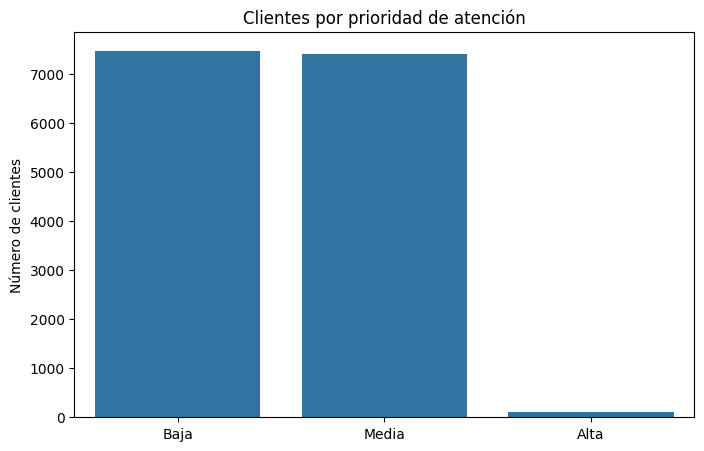

In [6]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.barplot(
    data=conteo_prioridad,
    x="Prioridad_Atencion",
    y="Numero_Clientes"
)
plt.title("Clientes por prioridad de atención")
plt.xlabel("")
plt.ylabel("Número de clientes")
plt.show()

### ¿Qué impacto económico está asociado a cada prioridad de atención?

In [7]:
# Agregar métricas financieras por prioridad de atención
impacto_financiero = (
    df.groupby("Prioridad_Atencion")
      .agg(
          Clientes=("ID_Cliente", "count"),
          Ingresos_Previstos_USD=("Ingresos_Previstos_USD", "sum"),
          Costo_Retencion=("Costo_Retencion_USD", "sum")
      )
      .reset_index()
)

impacto_financiero


,Prioridad_Atencion,Clientes,Ingresos_Previstos_USD,Costo_Retencion
0,Alta,117,1.167058e+06,10174
1,Baja,7472,7.448300e+07,627446
2,Media,7411,7.403608e+07,622758


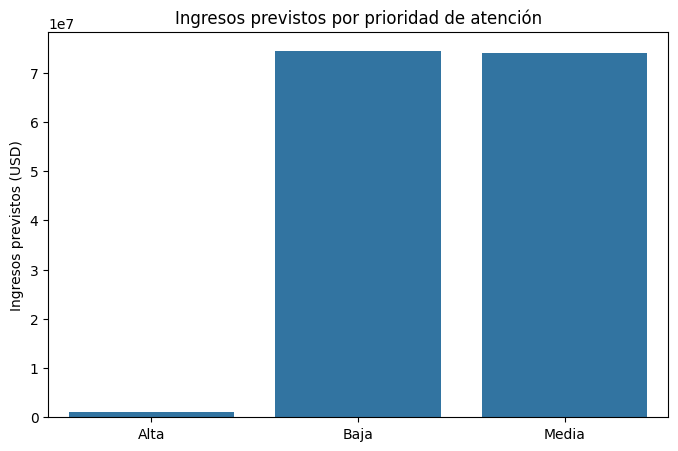

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=impacto_financiero,
    x="Prioridad_Atencion",
    y="Ingresos_Previstos_USD"
)
plt.title("Ingresos previstos por prioridad de atención")
plt.xlabel("")
plt.ylabel("Ingresos previstos (USD)")
plt.show()


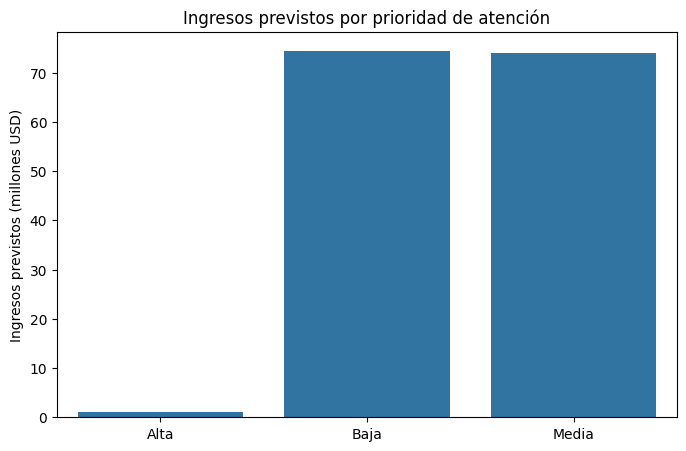

In [9]:
# Crear columna de ingresos en millones
impacto_financiero["Ingresos_M_USD"] = (
    impacto_financiero["Ingresos_Previstos_USD"] / 1_000_000
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=impacto_financiero,
    x="Prioridad_Atencion",
    y="Ingresos_M_USD"
)
plt.title("Ingresos previstos por prioridad de atención")
plt.ylabel("Ingresos previstos (millones USD)")
plt.xlabel("")
plt.show()


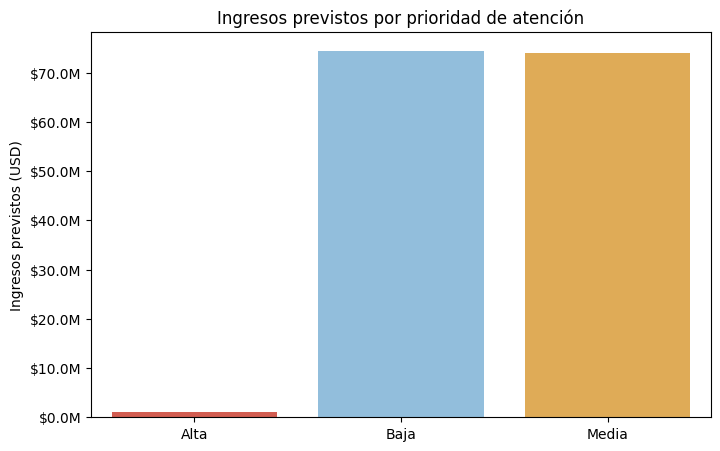

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

palette_prioridad = {
    "Alta": "#E74C3C",   # urgencia
    "Media": "#F5B041",  # atención
    "Baja": "#85C1E9"    # bajo riesgo
}

plt.figure(figsize=(8,5))
sns.barplot(
    data=impacto_financiero,
    x="Prioridad_Atencion",
    y="Ingresos_Previstos_USD",
    hue="Prioridad_Atencion",
    palette=palette_prioridad,
    legend=False
)

plt.title("Ingresos previstos por prioridad de atención")
plt.xlabel("")
plt.ylabel("Ingresos previstos (USD)")

# Formato ejecutivo del eje Y (opcional, recomendado)
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M")
)

plt.show()


### Crear el CSV final para Power BI

In [28]:
# Seleccionar columnas finales para Power BI

df["Ingresos_M_USD"] = df["Ingresos_Previstos_USD"] / 1_000_000

df_powerbi = df[
    [
        "ID_Cliente",
        "Sector_Negocio",
        "Tiempo_en_Servicio_Meses",
        "Probabilidad_Modelo",
        "Prioridad_Atencion",
        "Ingresos_Previstos_USD",
        "Ingresos_M_USD",
        "Costo_Retencion_USD"
    ]
]

# Exportar CSV final
df_powerbi.to_csv("servicore_churn_dashboard_powerbi.csv", index=False)

df_powerbi.head()


,ID_Cliente,Sector_Negocio,Tiempo_en_Servicio_Meses,Probabilidad_Modelo,Prioridad_Atencion,Ingresos_Previstos_USD,Ingresos_M_USD,Costo_Retencion_USD
0,100000,Finanzas,28,0.246972,Baja,4630.765584,0.004631,115
1,100001,Manufactura,22,0.264255,Media,8315.889833,0.008316,95
2,100002,Salud,45,0.213612,Baja,18138.531884,0.018139,89
3,100003,Finanzas,16,0.296174,Media,2805.261683,0.002805,121
4,100004,Retail,13,0.356988,Media,8274.013040,0.008274,42
